# M1.Ex1: Model Hours vs Marks

- Run: [**Open In Colab**](https://colab.research.google.com/github/HassanAlgoz/B5/blob/main/content/W3/M1/exercises/ex1_reg.ipynb)
- Raw Dataset: [Rounded_Student_Hours_Studied_vs_Marks_Dataset.csv](https://raw.githubusercontent.com/HassanAlgoz/B5/main/content/datasets/Rounded_Student_Hours_Studied_vs_Marks_Dataset.csv)

In [1]:
import pandas as pd
import sklearn

### Step 1. Load the data

In [2]:
fd = pd.read_csv("https://raw.githubusercontent.com/HassanAlgoz/B5/main/content/datasets/Rounded_Student_Hours_Studied_vs_Marks_Dataset.csv")

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split

# 1. Load the data directly from the URL
df = pd.read_csv("https://raw.githubusercontent.com/HassanAlgoz/B5/main/content/datasets/Rounded_Student_Hours_Studied_vs_Marks_Dataset.csv")

# 2. Define Features (X) and Target (y)
X = df[['Hours_Studied']] 
y = df['Marks']

# 3. Split the data 
# Note: No 'stratify' here because Marks are continuous numbers
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    random_state=4
)

print(f"Data loaded successfully! Training rows: {len(X_train)}")

Data loaded successfully! Training rows: 80


In [4]:
fd.head()

,Hours_Studied,Marks
0,4.76,46.27
1,3.00,34.30
2,2.08,33.63
3,4.04,47.81
4,9.49,66.26


### Step 2.a Assign variables `X` to the features and `y` to the target

In [5]:
feature_name = "Hours_Studied"
target_name = "Marks"

data = fd[[feature_name]]
target = fd[target_name]

### Step 2.b print the type of each

In [6]:
data.info()


<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 1 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Hours_Studied  100 non-null    float64
dtypes: float64(1)
memory usage: 932.0 bytes


In [7]:
target.info()

<class 'pandas.Series'>
RangeIndex: 100 entries, 0 to 99
Series name: Marks
Non-Null Count  Dtype  
--------------  -----  
100 non-null    float64
dtypes: float64(1)
memory usage: 932.0 bytes


In [8]:
print(f"Data shape: {data.shape}")

Data shape: (100, 1)


In [9]:
print(f"Target shape: {target.shape}")  

Target shape: (100,)


### Step 2.c identify whether the target is categorical or numerical & whether the task is regression or classification

In [10]:
data['Hours_Studied'] = data['Hours_Studied'].fillna(data['Hours_Studied'].mean())
target = target.fillna(target.mean())

In [11]:
data.dtypes

# It is numerical data, so we can use it for regression tasks.

Hours_Studied    float64
dtype: object

In [12]:
target.dtype

# It is numerical data, so we can use it for regression tasks.

dtype('float64')

### Step 3. Identify the number of samples and columns of both the data matrix and the target

In [13]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(data, target)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [14]:
model.coef_[0].round(2), model.intercept_.round(2)

(np.float64(5.23), np.float64(18.25))

### Step 4. Summarize the distribution of the data (min, max, median, mean, and standard deviation)

In [15]:
target.describe()

count    100.000000
mean      46.360200
std       14.284805
min       20.190000
25%       33.675000
50%       47.485000
75%       57.377500
max       73.260000
Name: Marks, dtype: float64

In [16]:
data.describe()

,Hours_Studied
count,100.000000
mean,5.376300
std,2.593013
min,1.050000
25%,3.175000
50%,5.565000
75%,7.255000
max,9.870000


### Step 5. Plot the feature vs the target

In [17]:
import numpy as np

x = np.linspace(data.min(), data.max(), num=300)
x[:3], x[-3:]

(array([[1.05      ],
        [1.07949833],
        [1.10899666]]),
 array([[9.81100334],
        [9.84050167],
        [9.87      ]]))

In [18]:
x = model.predict(data)
x[:3]

array([43.1382712 , 33.93724135, 29.12761211])

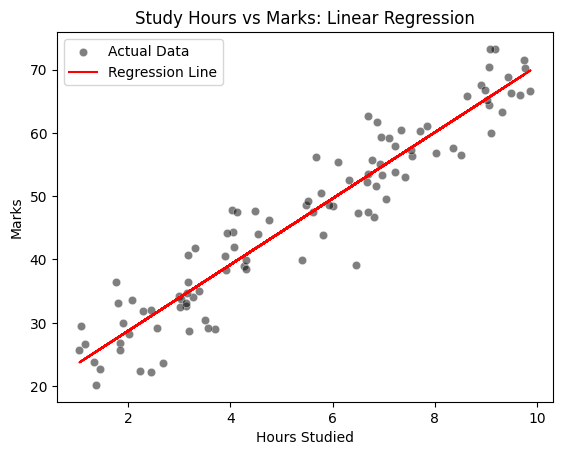

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Use the DataFrame 'df' instead of the 'data' bunch object
sns.scatterplot(
    x=df['Hours_Studied'], 
    y=df['Marks'],
    color="black",
    alpha=0.5,
    label="Actual Data"
)

# Use the model to predict based on the features
# Note: X was defined earlier as df[['Hours_Studied']]
target_predicted = model.predict(X)

# Plot the regression line
plt.plot(
    df['Hours_Studied'], 
    target_predicted, 
    color='red',
    label="Regression Line"
)

plt.title("Study Hours vs Marks: Linear Regression")
plt.xlabel("Hours Studied")
plt.ylabel("Marks")
plt.legend()
plt.show()

### Step 6. What is the relationship between the feature and the target? (increasing or decreasing or none)

Hours_Studied (feature) and Marks (target) is Increasing (also known as a Positive Linear Relationship).

### Step 7. Initialize a `LinearRegression` model

In [20]:
from sklearn.datasets import fetch_openml

# Load the penguins dataset from OpenML
data = fetch_openml(name="penguins", version=1, as_frame=True)
study_hours = data.frame

### Step 8. Split the dataset into train and test sets

In [21]:
import pandas as pd
from sklearn.model_selection import train_test_split

# 1. Load the data directly into a DataFrame
url = "https://raw.githubusercontent.com/HassanAlgoz/B5/main/content/datasets/Rounded_Student_Hours_Studied_vs_Marks_Dataset.csv"
df = pd.read_csv(url)

# 2. Define Features (X) and Target (y)
# We use double brackets for X to keep it as a 2D DataFrame (required by sklearn)
X = df[['Hours_Studied']] 
y = df['Marks']

# 3. Split the data
# REMOVED 'stratify' because Marks are continuous numbers (Regression), not categories.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    random_state=4
)

print(f"Success! Training set: {X_train.shape[0]} rows | Test set: {X_test.shape[0]} rows")

Success! Training set: 80 rows | Test set: 20 rows


### Step 9.a Train the model on the training set

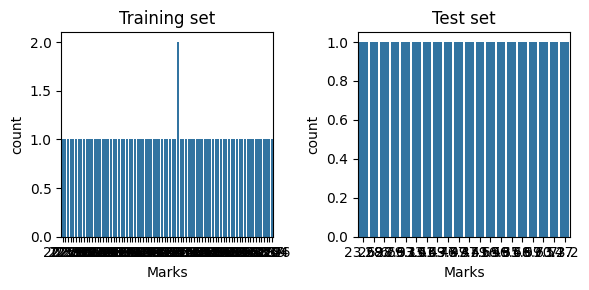

In [22]:
fig, ax = plt.subplots(1, 2, figsize=(6, 3))

sns.countplot(x=y_train, ax=ax[0], color=sns.color_palette()[0])
sns.countplot(x=y_test, ax=ax[1], color=sns.color_palette()[0])
ax[0].set_title("Training set")
ax[1].set_title("Test set")
plt.tight_layout()
# plt.gcf().savefig("../assets/lab_train_test_split_countplot.png", bbox_inches="tight", dpi=150)
plt.show()

### Step 9.b Identify the learned slope and the y-intercept of the model

In [23]:
from sklearn.linear_model import LinearRegression

# 1. Initialize and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# 2. Extract the slope and intercept
slope = model.coef_[0]
intercept = model.intercept_

print(f"Slope (m): {slope:.4f}")
print(f"Y-intercept (b): {intercept:.4f}")


Slope (m): 5.2513
Y-intercept (b): 18.5045


### Step 9.c how much marks do we get per 1 hour of study?

In [24]:
# Extract the slope (coefficient)
marks_per_hour = model.coef_[0]

print(f"You gain approximately {marks_per_hour:.2f} marks for every 1 hour of study.")

You gain approximately 5.25 marks for every 1 hour of study.


### Step 9.d how much does a 10 minutes increase of study time adds to our marks?

In [25]:
# Calculate the marks gained for 10 minutes (1/6 of an hour)
marks_per_10_minutes = model.coef_[0] * (10 / 60)

print(f"A 10-minute increase in study time adds approximately {marks_per_10_minutes:.2f} marks.")

A 10-minute increase in study time adds approximately 0.88 marks.


### Step 9.e if one doesn't study at all, how much marks do they get?

In [26]:
# Extract the y-intercept
baseline_mark = model.intercept_

print(f"If a student studies for 0 hours, the predicted mark is: {baseline_mark:.2f}")

If a student studies for 0 hours, the predicted mark is: 18.50


### Step 10. Evaluate the model on the test set

In [27]:
# Use the trained model to predict the test set
y_pred = model.predict(X_test)

In [28]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Calculate metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"--- Model Evaluation ---")
print(f"Mean Absolute Error: {mae:.2f}")
print(f"Mean Squared Error:  {mse:.2f}")
print(f"R-squared Score:     {r2:.4f}")

--- Model Evaluation ---
Mean Absolute Error: 4.76
Mean Squared Error:  29.26
R-squared Score:     0.8809


### Step 11. Take a sample of three rows from the test set and make a prediction on them and check whether they match the true label or not

In [29]:
import pandas as pd

# 1. Take a random sample of 3 rows from the test set
# We use random_state=1 so you can repeat this specific test
sample_X = X_test.sample(3, random_state=1)
sample_y_true = y_test.loc[sample_X.index]

# 2. Make predictions
sample_y_pred = model.predict(sample_X)

# 3. Create a comparison table
results = pd.DataFrame({
    'Hours Studied': sample_X.values.flatten(),
    'Actual Marks': sample_y_true.values,
    'Predicted Marks': sample_y_pred.round(2),
    'Difference (Error)': (sample_y_true.values - sample_y_pred).round(2)
})

print("--- Random Sample Prediction Check ---")
print(results)

--- Random Sample Prediction Check ---
   Hours Studied  Actual Marks  Predicted Marks  Difference (Error)
0           6.49         47.37            52.59               -5.22
1           3.56         29.19            37.20               -8.01
2           8.90         67.54            65.24                2.30


### Step 12. Plot the data and the regression line

c:\Users\feras\Desktop\SDAIA2\B5\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


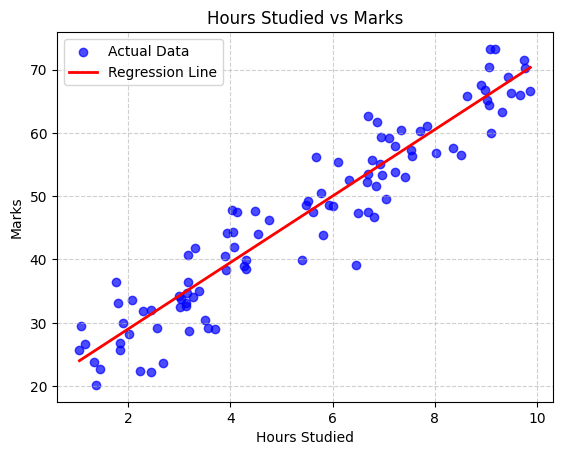

In [30]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Plot the actual data points from the dataset
plt.scatter(X, y, color='blue', label='Actual Data', alpha=0.7)

# 2. Create a range of values for the Hours_Studied (X-axis)
X_range = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)

# 3. Use the model to predict Marks for that range (Y-axis)
y_range = model.predict(X_range)

# 4. Plot the red regression line
plt.plot(X_range, y_range, color='red', linewidth=2, label='Regression Line')

# 5. Add labels and titles
plt.title('Hours Studied vs Marks')
plt.xlabel('Hours Studied')
plt.ylabel('Marks')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()